In [9]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2012.csv')

In [10]:
custom_priors = {"log_diameter": bmb.Prior("Normal", mu=0.6, sigma=0.07)}

model_cust_prior = bmb.Model("log_height ~ log_diameter + (1 | county) + (1 | county:plot_number)", data=df, priors=custom_priors)

results_cust_prior = model_cust_prior.fit(target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter, 1|county_sigma, 1|county_offset, 1|county:plot_number_sigma, 1|county:plot_number_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


In [12]:
az.summary(results_cust_prior,
           var_names=["Intercept", "log_diameter", "sigma", "1|county_sigma", "1|county:plot_number_sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.514,0.090,0.352,0.685,0.001,0.001,5559.0,3524.0,1.0
log_diameter,0.688,0.027,0.636,0.737,0.000,0.000,5948.0,3564.0,1.0
sigma,0.136,0.007,0.123,0.150,0.000,0.000,3243.0,2549.0,1.0
1|county_sigma,0.080,0.051,0.000,0.165,0.002,0.001,727.0,1444.0,1.0
1|county:plot_number_sigma,0.128,0.021,0.090,0.170,0.001,0.000,1186.0,2350.0,1.0


In [13]:
tabel = az.summary(results_cust_prior)
tabel[tabel['r_hat'] > 1.05]

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat


In [14]:
model_cust_prior

       Formula: log_height ~ log_diameter + (1 | county) + (1 | county:plot_number)
        Family: gaussian
          Link: mu = identity
  Observations: 246
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 2.5662, sigma: 0.8351)
            log_diameter ~ Normal(mu: 0.6, sigma: 0.07)
        
        Group-level effects
            1|county ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.8351))
            1|county:plot_number ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.8351))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.334)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

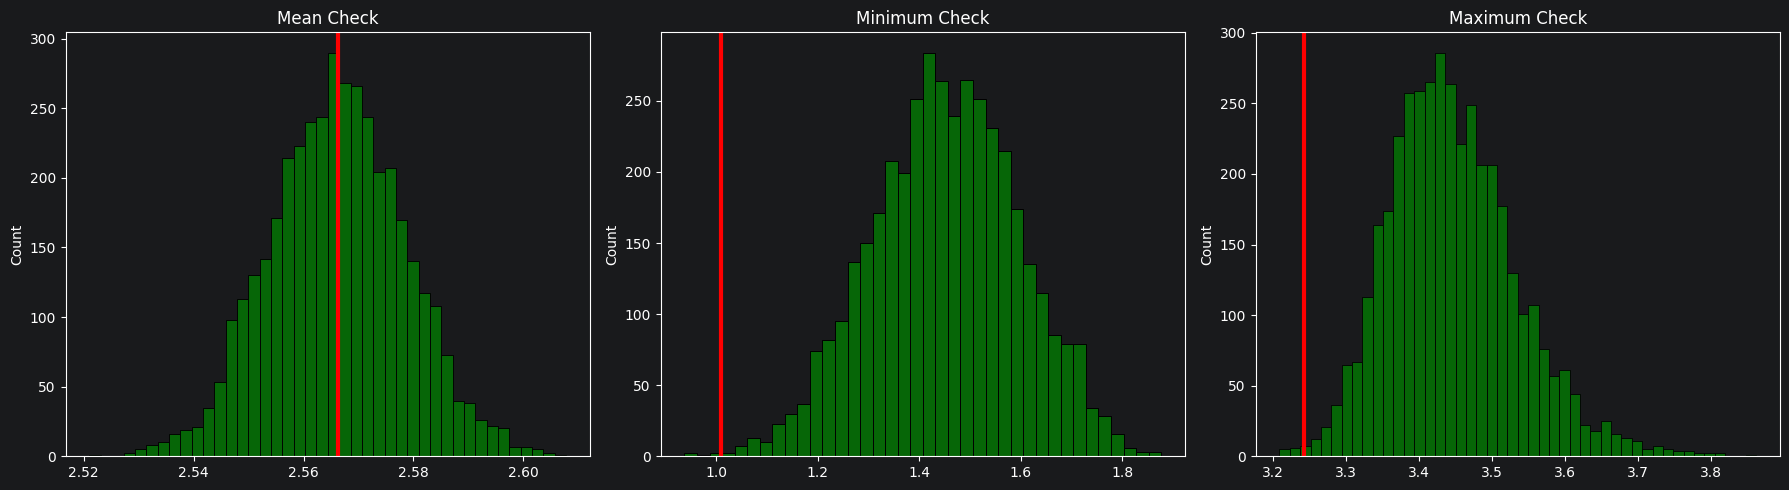

In [15]:
model_cust_prior.predict(results_cust_prior, kind="response")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sim_mean = (
    results_cust_prior.posterior_predictive["log_height"]
    .values.mean(axis=-1)
    .flatten()
)
sns.histplot(sim_mean, color="green", ax=axes[0])
axes[0].axvline(df["log_height"].mean(), color="red", linewidth=3)
axes[0].set_title("Mean Check")

sim_min = (
    results_cust_prior.posterior_predictive["log_height"]
    .values.min(axis=-1)
    .flatten()
)
sns.histplot(sim_min, color="green", ax=axes[1])
axes[1].axvline(df["log_height"].min(), color="red", linewidth=3)
axes[1].set_title("Minimum Check")

sim_max = (
    results_cust_prior.posterior_predictive["log_height"]
    .values.max(axis=-1)
    .flatten()
)
sns.histplot(sim_max, color="green", ax=axes[2])
axes[2].axvline(df["log_height"].max(), color="red", linewidth=3)
axes[2].set_title("Maximum Check")

plt.tight_layout()

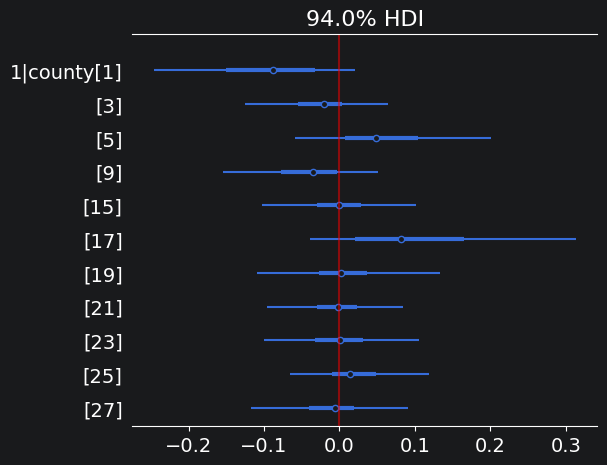

In [16]:
axes = az.plot_forest(results_cust_prior, var_names=["1|county"], combined = True)
for ax in axes:
    ax.axvline(0, color='red', alpha=0.5)

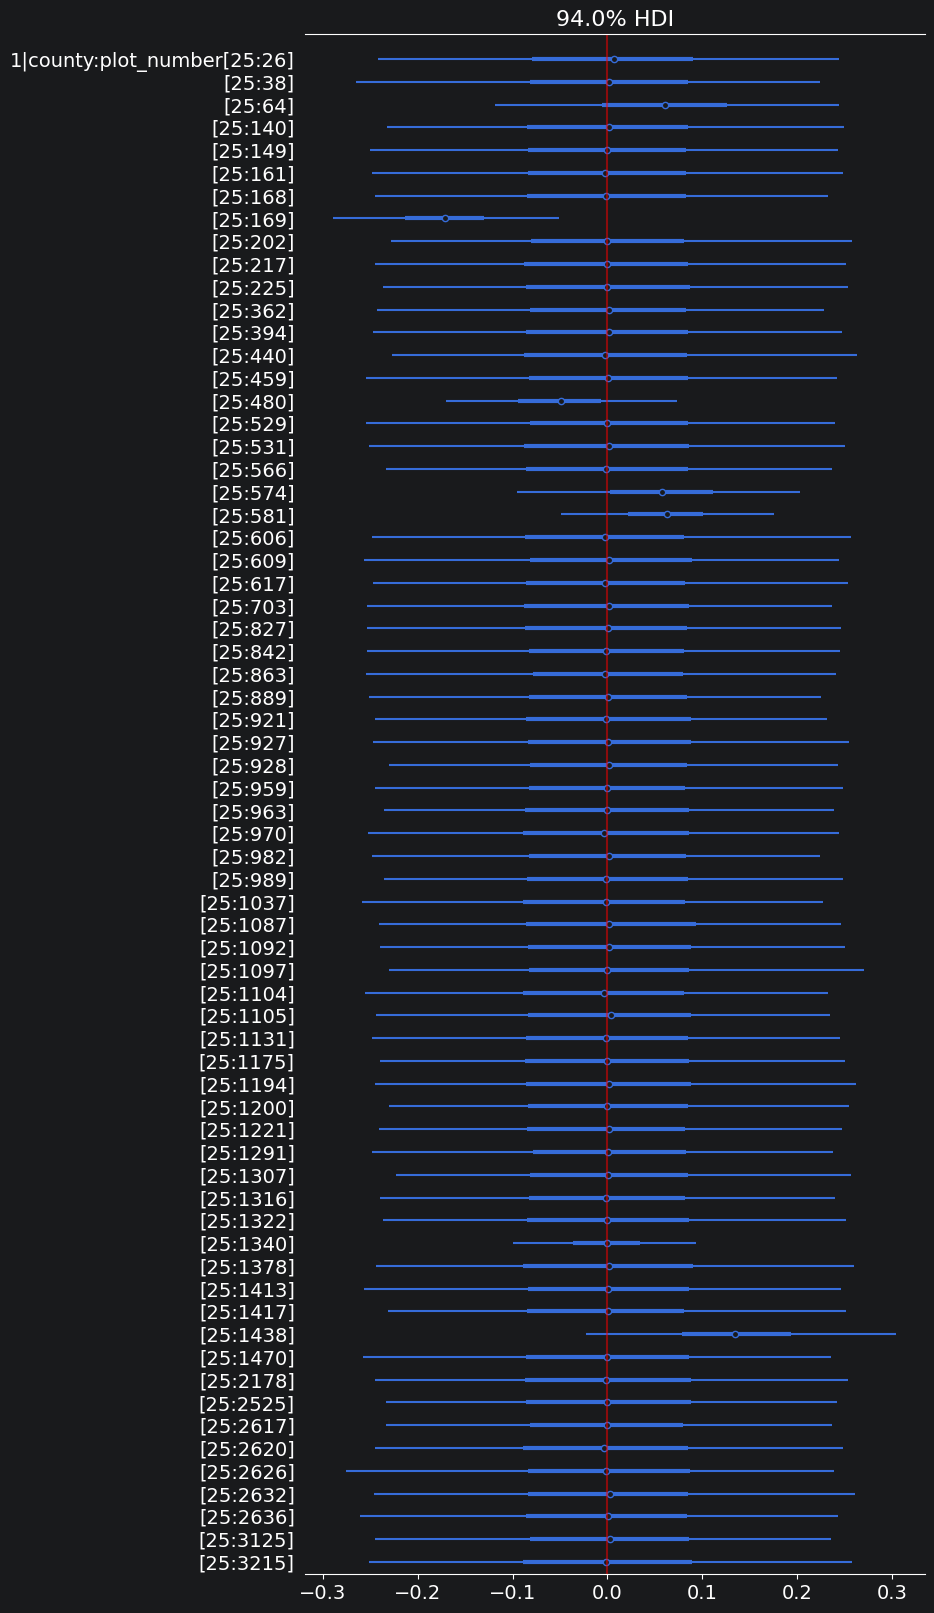

In [17]:
all_plot_names = results_cust_prior.posterior.coords["county:plot_number__factor_dim"].values
plots_in_county_25 = [name for name in all_plot_names if str(name).startswith("25:")]

axes = az.plot_forest(results_cust_prior, var_names=["1|county:plot_number"],
    coords={"county:plot_number__factor_dim": plots_in_county_25}, combined=True, figsize=(8, 20))

for ax in axes:
    ax.axvline(0, color='red', alpha=0.5)